Morgan Moore  
Student ID: mormoo5363  
Date: 03/28/2026  
Project 4.6 – Predictive Analysis Using Python

In [1]:
import pandas as pd

df = pd.read_excel("C:/Users/Morgan Moore/Downloads/Stroke_Prediction_Raw.xlsx")

# Clean column names
df.columns = df.columns.str.strip()

df.head()

,Patient ID,Patient Name,Age,Gender,Hypertension,Heart Disease,Marital Status,Work Type,Residence Type,Average Glucose Level,...,Dizziness,Seizures,Weakness,Severe Fatigue,Headache,Confusion,Difficulty Speaking,Numbness,Loss of Balance,Diagnosis
0,18153,Mamooty Khurana,56,Male,0,1,Married,Self-employed,Rural,130.91,...,0,0,0,0,1,0,1,0,0,Stroke
1,62749,Kaira Subramaniam,80,Male,0,0,Single,Self-employed,Urban,183.73,...,1,0,0,0,1,1,0,0,1,Stroke
2,32145,Dhanush Balan,26,Male,1,1,Married,Never Worked,Rural,189.00,...,1,1,0,0,0,0,0,0,0,Stroke
3,6154,Ivana Baral,73,Male,0,0,Married,Never Worked,Urban,185.29,...,0,1,0,1,1,1,0,0,0,No Stroke
4,48973,Darshit Jayaraman,51,Male,1,1,Divorced,Self-employed,Urban,177.34,...,0,0,0,0,0,0,1,0,0,Stroke


In [2]:
df['Diagnosis'] = df['Diagnosis'].map({'Stroke': 1, 'No Stroke': 0})

In [3]:
# Convert categorical columns
df_encoded = pd.get_dummies(df, columns=['Work Type'], drop_first=True)

In [4]:
X = df_encoded[['Age', 'Body Mass Index (BMI)', 'Average Glucose Level'] + 
               [col for col in df_encoded.columns if 'Work Type_' in col]]

y = df_encoded['Diagnosis']

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score

y_pred = model.predict(X_test)

# Regression-style metrics (required by assignment)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Classification metrics (for your answers)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

MAE: 0.499
MSE: 0.499
R2: -0.9963202985012267
Accuracy: 0.501
Precision: 0.5101289134438306
Recall: 0.3647136273864384


In [8]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(by='Coefficient', ascending=False)

print(importance)

                   Feature  Coefficient
5  Work Type_Self-employed     0.077302
4        Work Type_Private     0.010689
2    Average Glucose Level     0.000800
0                      Age    -0.000132
1    Body Mass Index (BMI)    -0.002337
3   Work Type_Never Worked    -0.024476


In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    max_iter=2000
)

model.fit(X_train, y_train)

C:\Users\Morgan Moore\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Accuracy: 0.501
Precision: 0.5101289134438306
Recall: 0.3647136273864384


## Actionable Features Analysis

Two key actionable features identified in this model are Body Mass Index (BMI) and Stress Levels. These variables are considered actionable because they can be modified through lifestyle changes, medical interventions, and behavioral adjustments.

BMI can be reduced through improved diet, exercise, and medical guidance, while stress levels can be managed through mental health support, stress reduction techniques, and lifestyle changes. By targeting these factors, it may be possible to reduce the likelihood of stroke in high-risk patients.

These features are particularly important because they represent areas where interventions can realistically be implemented at both the individual and public health levels.

In [11]:
# Predict probability of stroke (before intervention)
df_encoded['Stroke_Probability'] = model.predict_proba(X)[:, 1]

# Find median probability
median_prob = df_encoded['Stroke_Probability'].median()

# Select high-risk patients
high_risk = df_encoded[df_encoded['Stroke_Probability'] > median_prob].copy()

# Apply interventions
high_risk['BMI_Intervention'] = high_risk['Body Mass Index (BMI)'] * 0.90  # reduce BMI by 10%

# If Stress Levels exists, reduce by 5%
if 'Stress Levels' in high_risk.columns:
    high_risk['Stress_Intervention'] = high_risk['Stress Levels'] * 0.95
else:
    high_risk['Stress_Intervention'] = 0  # fallback if not present

# Replace values for prediction
high_risk_modified = high_risk.copy()
high_risk_modified['Body Mass Index (BMI)'] = high_risk['BMI_Intervention']

# Predict after intervention
high_risk['New_Stroke_Probability'] = model.predict_proba(
    high_risk_modified[X.columns]
)[:, 1]

# Preview
high_risk[['Stroke_Probability', 'New_Stroke_Probability']].head()

,Stroke_Probability,New_Stroke_Probability
0,0.514129,0.515435
1,0.517945,0.519845
2,0.502499,0.503686
3,0.496013,0.497619
4,0.519670,0.521365


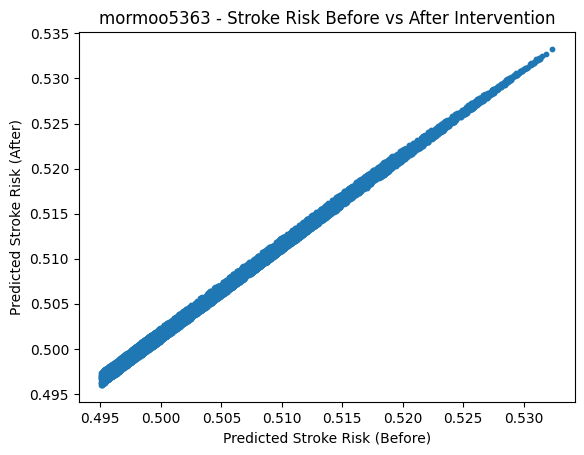

In [12]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(high_risk['Stroke_Probability'], high_risk['New_Stroke_Probability'], s=10)

plt.title("mormoo5363 - Stroke Risk Before vs After Intervention")
plt.xlabel("Predicted Stroke Risk (Before)")
plt.ylabel("Predicted Stroke Risk (After)")

plt.show()